# CHAPTER 2 前向传播

在第一章中，我们从感知机出发，认识了神经网络的基本结构——输入层、隐藏层、输出层，以及层与层之间全连接的权重网络。这一章我们将聚焦神经网络最核心的工作机制：**前向传播**（Forward Propagation），即数据从输入层流向输出层的完整过程。

在前向传播中，每一层都在重复同样的两步运算：

1. **线性变换**：$\mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}$
2. **非线性激活**：$\mathbf{a}^{(l)} = h(\mathbf{z}^{(l)})$

其中，激活函数 $h(\cdot)$ 是整个前向传播中**最关键的一环**——它决定了神经网络是否能学习复杂的非线性模式，也直接塑造了最终输出层的面貌。经过层层激活函数的筛选与变换，数据被逐步映射到越来越适合任务目标的特征空间。

## 2.1 前向传播过程

回顾第一章介绍的神经网络结构，前向传播的过程就是把输入数据一层一层向前传递，直到得到最终输出。整个过程可以用下面的流程图概括：

$$
\boxed{\mathbf{x}} 
\;\xrightarrow{\mathbf{W}^{(1)},\mathbf{b}^{(1)}}\; 
\boxed{\mathbf{z}^{(1)} = \mathbf{W}^{(1)}\mathbf{x} + \mathbf{b}^{(1)}} 
\;\xrightarrow{h(\cdot)}\; 
\boxed{\mathbf{a}^{(1)} = h(\mathbf{z}^{(1)})}
\;\xrightarrow{\mathbf{W}^{(2)},\mathbf{b}^{(2)}}\; 
\boxed{\cdots}
\;\longrightarrow\;
\boxed{\hat{\mathbf{y}}}
$$

对于第 $l$ 层的每个神经元，前向传播的计算可以归纳为统一的形式：

$$
\begin{aligned}
z_j^{(l)} &= \sum_{i} w_{ji}^{(l)} a_i^{(l-1)} + b_j^{(l)} \quad &\text{(加权求和，线性变换)} \\[4pt]
a_j^{(l)} &= h(z_j^{(l)}) \quad &\text{(激活函数，非线性映射)}
\end{aligned}
$$

其中 $\mathbf{a}^{(0)} = \mathbf{x}$ 是原始输入。

> 在整个前向传播的过程中，**线性变换只改变数据的偏移和方向，而激活函数引入了弯曲和折叠**——正是这种非线性让神经网络能够表达任意复杂的函数。

## 2.2 激活函数

### 2.2.1 为什么要有激活函数？

在第一章中我们已经多次提到了激活函数，你可能会产生疑惑：输入向量与权重做内积、加上偏置，直接传到下一层不就好了，何必还要多这一步"激活"？

但你可以这样想：如果每一层都只做线性运算（内积 + 偏置），那么——

$$
\begin{aligned}
\mathbf{a}^{(1)} &= \mathbf{W}^{(1)} \mathbf{x} + \mathbf{b}^{(1)} \\[2pt]
\mathbf{a}^{(2)} &= \mathbf{W}^{(2)} \mathbf{a}^{(1)} + \mathbf{b}^{(2)} = \mathbf{W}^{(2)}(\mathbf{W}^{(1)} \mathbf{x} + \mathbf{b}^{(1)}) + \mathbf{b}^{(2)} \\[2pt]
&= \underbrace{\mathbf{W}^{(2)}\mathbf{W}^{(1)}}_{\text{一个矩阵}} \mathbf{x} + \underbrace{(\mathbf{W}^{(2)}\mathbf{b}^{(1)} + \mathbf{b}^{(2)})}_{\text{一个向量}}
\end{aligned}
$$

无论堆叠多少层，最终的变换都可以等价为**一层线性变换**。也就是说，深度的优势被完全抹去了——你做了再多层的运算，本质上和一层没有任何区别。

因此，神经网络中**绝对不能只用线性运算作为层次的划分**，必须在每一层之间插入**非线性映射**。而神经网络的结构已经告诉我们答案了——在每层权重运算之后、将结果传递给下一层之前，正是插入这个非线性映射的位置。

<img src="../attachment/图2-1.jpg" width="700" style="display: block; margin: 0 auto;" >

这一非线性映射 $h(\cdot)$，就是我们所说的**激活函数**（Activation Function）。

### 2.2.2 激活函数带来了什么？

上面我们提到激活函数具有平滑或者折叠空间的能力，如果现在给你一条直线（对应的是一个输入），如果我能去无限的折叠它，理论上是不是就能够去拟合任意的曲线。如果给你一个平面，我无限地折叠，是不是就可以去拟合任意的曲面。不论维度有多少，**折叠空间** + **增加折叠次数**，总能达到我们的最终目的。

折叠空间对应于使用ReLu激活函数、增加折叠次数对应于增加神经元个数。

这实际上就是**通用逼近定理**（Universal Approximation Theorem）的精髓所在：

> 一个具有**单个隐藏层**、包含**足够多神经元**、使用非线性激活函数（如 Sigmoid 或 ReLU）的前馈神经网络，能够以任意精度逼近定义在紧致集上的任意连续函数。

下面我们用一个直观的例子来验证这一点。我们构造一条非线性曲线作为目标函数，然后分别训练**隐藏层神经元数为 5、10、20、40** 的四个神经网络去拟合它。

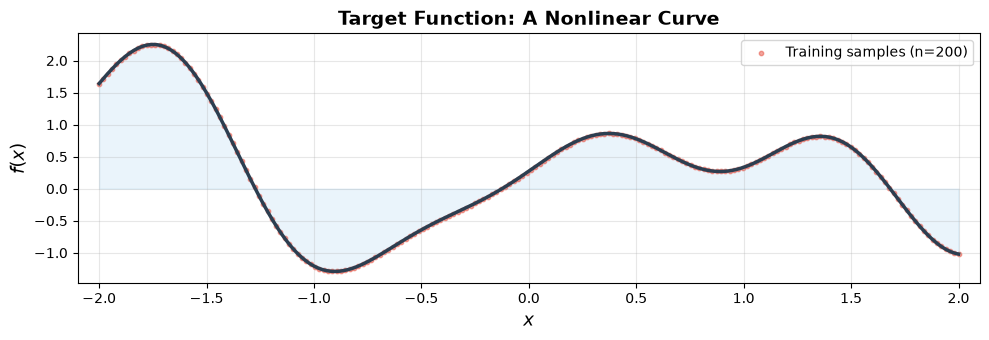

目标函数公式: f(x) = sin(2.5x) + 0.6·cos(4x+0.5) + 0.15x² + 0.3·sin(6x-1)
训练样本数: 200, x 范围: [-2, 2]


In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ============================================================
# 1. 构造目标函数（非线性曲线）
# ============================================================
def target_function(x):
    """一个包含多个波峰波谷的非线性曲线"""
    return (np.sin(2.5 * x) +
            0.6 * np.cos(4.0 * x + 0.5) +
            0.15 * x**2 +
            0.3 * np.sin(6.0 * x - 1.0))

# 生成训练数据: 200个样本点, x ∈ [-2, 2]
# 缩小 x 轴范围可以减少振荡周期，让有限神经元更容易拟合
X_train = np.linspace(-2, 2, 200).reshape(-1, 1)
y_train = target_function(X_train).ravel()

# 先看看目标函数的形状
fig, ax = plt.subplots(figsize=(10, 3.5))
X_plot = np.linspace(-2, 2, 500)
ax.plot(X_plot, target_function(X_plot), '#2C3E50', linewidth=2.5)
ax.fill_between(X_plot, target_function(X_plot), alpha=0.1, color='#3498DB')
ax.scatter(X_train.ravel(), y_train, s=10, alpha=0.5, c='#E74C3C', label='Training samples (n=200)')
ax.set_xlabel('$x$', fontsize=13)
ax.set_ylabel('$f(x)$', fontsize=13)
ax.set_title('Target Function: A Nonlinear Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-2.1, 2.1)
plt.tight_layout()
plt.show()

print("目标函数公式: f(x) = sin(2.5x) + 0.6·cos(4x+0.5) + 0.15x² + 0.3·sin(6x-1)")
print(f"训练样本数: {len(X_train)}, x 范围: [-2, 2]")

In [6]:
# ============================================================
# 2. 从零实现单隐层神经网络（ReLU 激活函数 + Adam 优化器）
# ============================================================
class SimpleNN:
    """单隐藏层神经网络，使用 ReLU 激活函数 + Adam 优化器"""
    def __init__(self, hidden_size, lr=0.01, epochs=20000):
        self.hidden_size = hidden_size
        self.lr = lr
        self.epochs = epochs
        self.loss_history = []

    def _relu(self, z):
        return np.maximum(0, z)

    def _relu_grad(self, z):
        return (z > 0).astype(float)

    def fit(self, X, y):
        n, d = X.shape
        y = y.reshape(-1, 1)

        # He 初始化（适合 ReLU 激活的权重初始化方法）
        self.W1 = np.random.randn(d, self.hidden_size) * np.sqrt(2.0 / max(d, 1))
        self.b1 = np.zeros((1, self.hidden_size))
        self.W2 = np.random.randn(self.hidden_size, 1) * np.sqrt(2.0 / max(self.hidden_size, 1))
        self.b2 = np.zeros((1, 1))

        # Adam 优化器状态
        mW1, vW1 = np.zeros_like(self.W1), np.zeros_like(self.W1)
        mb1, vb1 = np.zeros_like(self.b1), np.zeros_like(self.b1)
        mW2, vW2 = np.zeros_like(self.W2), np.zeros_like(self.W2)
        mb2, vb2 = np.zeros_like(self.b2), np.zeros_like(self.b2)
        beta1, beta2, eps = 0.9, 0.999, 1e-8

        for epoch in range(self.epochs):
            # ---- 前向传播 ----
            z1 = X @ self.W1 + self.b1           # 线性变换
            a1 = self._relu(z1)                   # ReLU 激活（关键！）
            y_pred = a1 @ self.W2 + self.b2       # 输出层（线性）

            # ---- 计算损失 (MSE) ----
            loss = np.mean((y_pred - y) ** 2)
            self.loss_history.append(loss)

            # ---- 反向传播 ----
            dy = (2.0 / n) * (y_pred - y)
            dW2 = a1.T @ dy
            db2 = np.sum(dy, axis=0, keepdims=True)

            da1 = dy @ self.W2.T
            dz1 = da1 * self._relu_grad(z1)
            dW1 = X.T @ dz1
            db1 = np.sum(dz1, axis=0, keepdims=True)

            # ---- Adam 更新 ----
            t = epoch + 1
            # W1
            mW1 = beta1 * mW1 + (1 - beta1) * dW1
            vW1 = beta2 * vW1 + (1 - beta2) * dW1**2
            self.W1 -= self.lr * (mW1 / (1 - beta1**t)) / (np.sqrt(vW1 / (1 - beta2**t)) + eps)
            # b1
            mb1 = beta1 * mb1 + (1 - beta1) * db1
            vb1 = beta2 * vb1 + (1 - beta2) * db1**2
            self.b1 -= self.lr * (mb1 / (1 - beta1**t)) / (np.sqrt(vb1 / (1 - beta2**t)) + eps)
            # W2
            mW2 = beta1 * mW2 + (1 - beta1) * dW2
            vW2 = beta2 * vW2 + (1 - beta2) * dW2**2
            self.W2 -= self.lr * (mW2 / (1 - beta1**t)) / (np.sqrt(vW2 / (1 - beta2**t)) + eps)
            # b2
            mb2 = beta1 * mb2 + (1 - beta1) * db2
            vb2 = beta2 * vb2 + (1 - beta2) * db2**2
            self.b2 -= self.lr * (mb2 / (1 - beta1**t)) / (np.sqrt(vb2 / (1 - beta2**t)) + eps)

    def predict(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = self._relu(z1)
        return (a1 @ self.W2 + self.b2).ravel()

# ============================================================
# 3. 分别训练隐藏层神经元数为 5、10、20、40 的四个网络
# ============================================================
hidden_sizes = [5, 10, 20, 40]
models = {}

for h in hidden_sizes:
    print(f"训练隐藏层神经元数 = {h:2d} 的神经网络 ({h:2d} 个 ReLU 单元)...", end=" ")
    np.random.seed(42)  # 重置种子，保证大模型的前 h 个神经元与小模型初始化一致
    nn = SimpleNN(hidden_size=h, lr=0.01, epochs=20000)
    nn.fit(X_train, y_train)
    models[h] = nn
    print(f"完成! 最终 MSE = {nn.loss_history[-1]:.6f}")

print("\n✅ 四个网络全部训练完成！")
print(f"\n总结：随着隐藏层神经元增多，MSE 逐步下降——")
print(f"  5 个神经元 (最多 6 段折线)  → MSE = {models[5].loss_history[-1]:.6f}")
print(f"  10 个神经元 (最多 11 段折线) → MSE = {models[10].loss_history[-1]:.6f}")
print(f"  20 个神经元 (最多 21 段折线) → MSE = {models[20].loss_history[-1]:.6f}")
print(f"  40 个神经元 (最多 41 段折线) → MSE = {models[40].loss_history[-1]:.6f}")

训练隐藏层神经元数 =  5 的神经网络 ( 5 个 ReLU 单元)... 完成! 最终 MSE = 0.116933
训练隐藏层神经元数 = 10 的神经网络 (10 个 ReLU 单元)... 完成! 最终 MSE = 0.070699
训练隐藏层神经元数 = 20 的神经网络 (20 个 ReLU 单元)... 完成! 最终 MSE = 0.057529
训练隐藏层神经元数 = 40 的神经网络 (40 个 ReLU 单元)... 完成! 最终 MSE = 0.000709

✅ 四个网络全部训练完成！

总结：随着隐藏层神经元增多，MSE 逐步下降——
  5 个神经元 (最多 6 段折线)  → MSE = 0.116933
  10 个神经元 (最多 11 段折线) → MSE = 0.070699
  20 个神经元 (最多 21 段折线) → MSE = 0.057529
  40 个神经元 (最多 41 段折线) → MSE = 0.000709


<>:36: SyntaxWarning: invalid escape sequence '\L'
<>:36: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_5685/2917532879.py:36: SyntaxWarning: invalid escape sequence '\L'
  'More ReLU Neurons $\Longrightarrow$ More Linear Segments $\Longrightarrow$ Better Approximation',


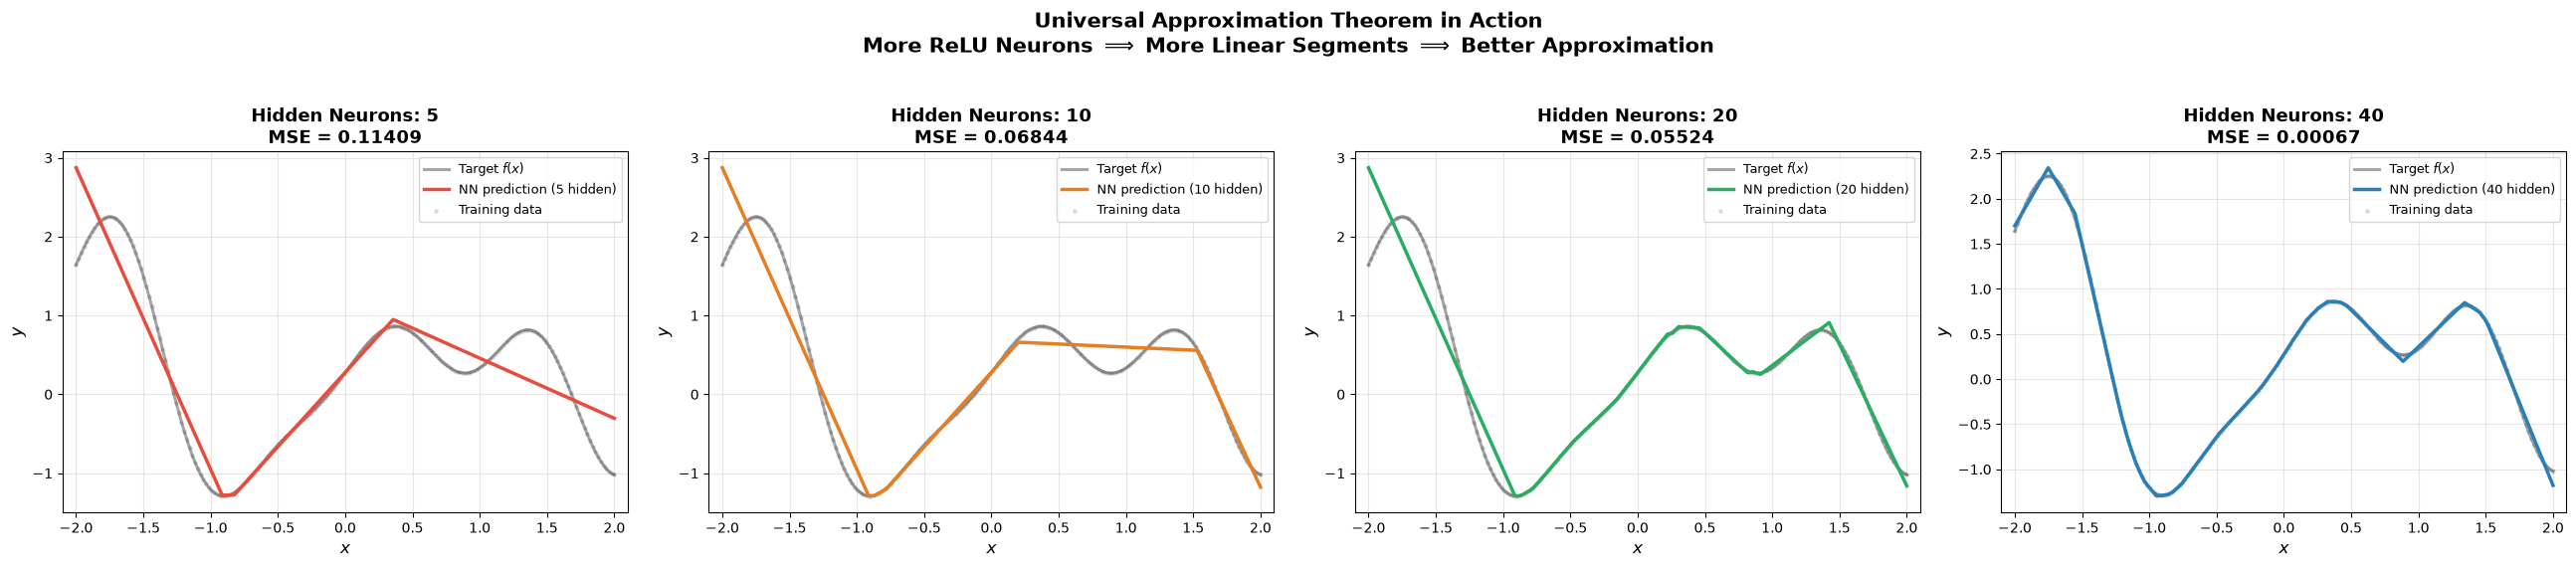

In [7]:
# ============================================================
# 4. 可视化对比：不同隐藏层神经元数量的拟合效果
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(26, 5.5))

# 测试范围与训练范围一致，避免外推
X_test = np.linspace(-2, 2, 500).reshape(-1, 1)
y_true = target_function(X_test).ravel()

# 为不同神经元数量设置不同颜色：少→多，颜色从暖到冷
colors = ['#E74C3C', '#E67E22', '#27AE60', '#2980B9']

for ax, h, color in zip(axes, hidden_sizes, colors):
    y_pred = models[h].predict(X_test)
    mse = np.mean((y_pred - y_true) ** 2)

    # 目标函数（黑色半透明）
    ax.plot(X_test, y_true, 'k-', linewidth=2.2, alpha=0.35,
            label='Target $f(x)$')
    # 神经网络拟合结果
    ax.plot(X_test, y_pred, color=color, linewidth=2.5,
            label=f'NN prediction ({h} hidden)')
    # 训练样本点
    ax.scatter(X_train.ravel(), y_train, s=6, alpha=0.2,
               c='gray', label='Training data')

    ax.set_title(f'Hidden Neurons: {h}\nMSE = {mse:.5f}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('$x$', fontsize=12)
    ax.set_ylabel('$y$', fontsize=12)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_xlim(-2.1, 2.1)
    ax.grid(True, alpha=0.3)

fig.suptitle('Universal Approximation Theorem in Action\n'
             'More ReLU Neurons $\Longrightarrow$ More Linear Segments $\Longrightarrow$ Better Approximation',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

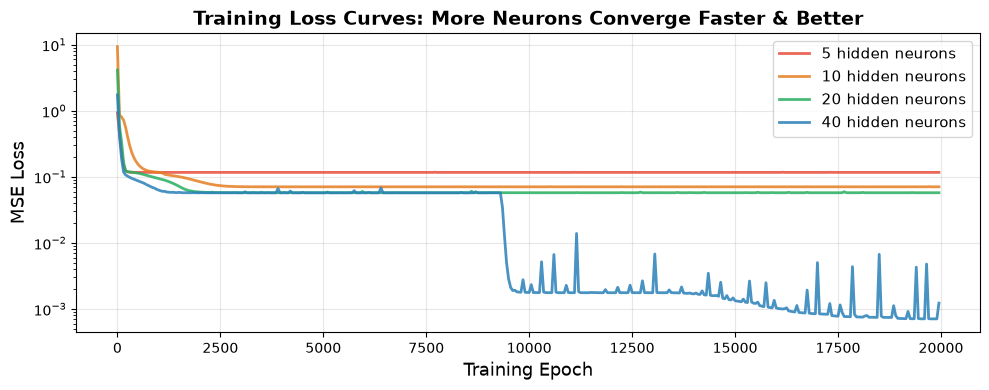

In [8]:
# ============================================================
# 5. 损失曲线对比：训练过程可视化
# ============================================================
fig, ax = plt.subplots(figsize=(10, 4))

for h, color in zip(hidden_sizes, colors):
    losses = models[h].loss_history
    # 每隔 50 步采样一次使曲线更平滑
    steps = np.arange(0, len(losses), 50)
    sampled_losses = [losses[i] for i in steps]
    ax.plot(steps, sampled_losses, color=color, linewidth=2, alpha=0.85,
            label=f'{h} hidden neurons')

ax.set_xlabel('Training Epoch', fontsize=13)
ax.set_ylabel('MSE Loss', fontsize=13)
ax.set_title('Training Loss Curves: More Neurons Converge Faster & Better',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')  # 对数尺度更清晰地展示收敛过程
plt.tight_layout()
plt.show()



### 2.2.3 ReLU 的分段线性本质

为什么隐藏层神经元越多，拟合越好？答案藏在 **ReLU 激活函数的数学本质**里。

ReLU 的定义是 $h(z) = \max(0, z)$，它是一个**分段线性函数**——在 $z \le 0$ 的区域输出恒为零，在 $z > 0$ 的区域输出一条斜线。在单隐层网络中，每个隐藏神经元就等价于在输入空间添加了一个"折弯点"（kink）：

这就是**通用逼近定理**在 ReLU 网络中的具体实现机制：激活函数赋予了神经网络"弯曲"空间的能力，而神经元数量决定了能弯曲多少次。两者缺一不可——没有激活函数，再多神经元也只是线性；没有足够神经元，激活函数也无从发挥。

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_5685/694538405.py:14: SyntaxWarning: invalid escape sequence '\l'
  ax.fill_between(z, relu, 0, where=(z <= 0), color='#E74C3C', alpha=0.1, label='inactive region ($z \leq 0$)')


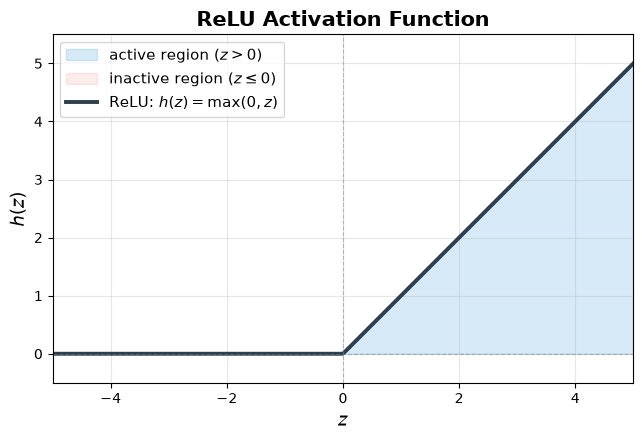

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 绘制 ReLU 激活函数图像
# ============================================================
z = np.linspace(-5, 5, 500)
relu = np.maximum(0, z)

fig, ax = plt.subplots(figsize=(8, 4.5))

# 填充区域
ax.fill_between(z, relu, 0, where=(z >= 0), color='#3498DB', alpha=0.2, label='active region ($z>0$)')
ax.fill_between(z, relu, 0, where=(z <= 0), color='#E74C3C', alpha=0.1, label='inactive region ($z \leq 0$)')

# ReLU 曲线
ax.plot(z, relu, '#2C3E50', linewidth=2.8, label=r'ReLU: $h(z) = \max(0, z)$')

# 坐标轴样式
ax.axhline(y=0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('$z$', fontsize=13)
ax.set_ylabel('$h(z)$', fontsize=13)
ax.set_title('ReLU Activation Function', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.set_xlim(-5, 5)
ax.set_ylim(-0.5, 5.5)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

## 小结

在学完这一章的内容以后我相信你对神经网络的前向传播有了一个很好的直觉，神经网络本质上就是在做拟合。

对于基本的一元线性回归问题，从神经网络的角度讲，它实际上构建了一个输入为一，输出为一的一层神经网络。而且没有用激活函数，所以我们看到，在对他进行不断优化的过程中，只有斜率和截距在不断变化。

<img src="../attachment/图2-2.jpg" width="700" style="display: block; margin: 0 auto;" >

一元/多元回归问题经常作为机器学习的入门案例来讲，从损失函数和参数优化的角度看，与深度学习的逻辑如出一辙。但是真正带领我们踏入深度学习大门的是激活函数，激活函数给了我们变换空间的自由。

最后，思考两个小问题：

1. 在2.2.2中我说到，只要无限地增加折叠次数就可以达到逼近任意连续函数的结果，这个说法实际上是存在瑕疵的。如果我所有的折叠的点在一个部位呢？所以不光要增加次数，而且要求折叠的点位选取尽量达到最优解。这实际上就是我们下一章节中要说到的**学习**的思想所在。

> 通用逼近定理告诉我们"能做到"，而**学习**告诉我们"怎么做"。宽度（神经元数量）决定了表达能力的**上限**，训练（参数优化）决定了能否**达到**这个上限。

2. 我们这一章中举的例子都是输入输出层神经元数量相同的例子。从拟合的角度出发来理解神经网络，即在保证向量空间维度不变的条件下，利用激活函数折叠空间，从而使一条直线变成一条弯曲的折线，去拟合我们的目标函数。在当前这一章，我们是这样去理解神经网络的。那么如果我改变了维度呢？从2个输入变成4个输出呢（维度明显发生改变）？我们是否能用相同的逻辑去看待它？
